In [2]:
import numpy as np
import pandas as pd

## Data loading using json

In [3]:
import json

In [4]:
a = open(r"C:\Users\tanaa\Downloads\customer_data (14).json","r")
data = a.read()
json_df = json.loads(data)

json_data = pd.json_normalize(json_df)
json_data

,customer_id,purchase_count,avg_purchase_value
0,1,16,138
1,2,10,858
2,3,3,917
3,4,13,927
4,5,7,924
...,...,...,...
95,96,14,834
96,97,19,605
97,98,15,243
98,99,5,198


## Data loading using csv

In [5]:
csv_data = pd.read_csv(r"C:\Users\tanaa\Downloads\customer_data (4).csv")
csv_data

,customer_id,age,gender,income,churn
0,1,56,Male,23748,1
1,2,46,Female,33545,1
2,3,32,Female,86199,0
3,4,25,Female,54766,0
4,5,38,Male,93530,0
...,...,...,...,...,...
95,96,59,Male,70108,1
96,97,56,Female,58467,0
97,98,58,Female,43328,0
98,99,45,Male,23987,0


## Data loading using sql

In [6]:
import sqlite3

In [7]:
conn = sqlite3.connect(r"C:\Users\tanaa\Downloads\database.db")

df_sql = pd.DataFrame({
    "customer_id": range(1, 101),
    "credit_score": np.random.randint(300, 850, 100),
    "loan_amount": np.random.randint(5000, 50000, 100)
})

df_sql.to_sql("customer_income", conn, if_exists='replace', index=False)

conn.close()


In [8]:
conn = sqlite3.connect(r"C:\Users\tanaa\Downloads\database.db")

df_sql = pd.read_sql("SELECT * FROM customer_income", conn)
df_sql

,customer_id,credit_score,loan_amount
0,1,526,21104
1,2,733,44214
2,3,467,13038
3,4,547,45922
4,5,578,47545
...,...,...,...
95,96,706,26620
96,97,360,47763
97,98,374,46153
98,99,405,6905


## Load Data from API

In [10]:
df_api = pd.DataFrame({
    "customer_id": range(1, 101),
    "inflation_rate": np.random.uniform(3, 7, 100),
    "gdp_growth": np.random.uniform(4, 8, 100)
})
df_api

,customer_id,inflation_rate,gdp_growth
0,1,6.734559,5.834825
1,2,4.890592,6.536832
2,3,4.801006,6.231965
3,4,5.638586,5.707928
4,5,3.788375,6.829064
...,...,...,...
95,96,3.242378,6.743139
96,97,4.586762,6.837436
97,98,6.229402,4.832700
98,99,5.230690,4.397034


## Merge

In [11]:
df = csv_data.copy()

df = df.merge(json_data, on="customer_id", how="left")
df = df.merge(df_sql, on="customer_id", how="left")
df = df.merge(df_api, on="customer_id", how="left")

print("Final Shape:", df.shape)
df

Final Shape: (100, 11)


,customer_id,age,gender,income,churn,purchase_count,avg_purchase_value,credit_score,loan_amount,inflation_rate,gdp_growth
0,1,56,Male,23748,1,16,138,526,21104,6.734559,5.834825
1,2,46,Female,33545,1,10,858,733,44214,4.890592,6.536832
2,3,32,Female,86199,0,3,917,467,13038,4.801006,6.231965
3,4,25,Female,54766,0,13,927,547,45922,5.638586,5.707928
4,5,38,Male,93530,0,7,924,578,47545,3.788375,6.829064
...,...,...,...,...,...,...,...,...,...,...,...
95,96,59,Male,70108,1,14,834,706,26620,3.242378,6.743139
96,97,56,Female,58467,0,19,605,360,47763,4.586762,6.837436
97,98,58,Female,43328,0,15,243,374,46153,6.229402,4.832700
98,99,45,Male,23987,0,5,198,405,6905,5.230690,4.397034


## Data understanding 

In [12]:
print(df.head())

   customer_id  age  gender  income  churn  purchase_count  \
0            1   56    Male   23748      1              16   
1            2   46  Female   33545      1              10   
2            3   32  Female   86199      0               3   
3            4   25  Female   54766      0              13   
4            5   38    Male   93530      0               7   

   avg_purchase_value  credit_score  loan_amount  inflation_rate  gdp_growth  
0                 138           526        21104        6.734559    5.834825  
1                 858           733        44214        4.890592    6.536832  
2                 917           467        13038        4.801006    6.231965  
3                 927           547        45922        5.638586    5.707928  
4                 924           578        47545        3.788375    6.829064  


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         100 non-null    int64  
 1   age                 100 non-null    int64  
 2   gender              100 non-null    object 
 3   income              100 non-null    int64  
 4   churn               100 non-null    int64  
 5   purchase_count      100 non-null    int64  
 6   avg_purchase_value  100 non-null    int64  
 7   credit_score        100 non-null    int64  
 8   loan_amount         100 non-null    int64  
 9   inflation_rate      100 non-null    float64
 10  gdp_growth          100 non-null    float64
dtypes: float64(2), int64(8), object(1)
memory usage: 8.7+ KB
None


In [14]:
print(df.describe())

       customer_id         age       income       churn  purchase_count  \
count   100.000000  100.000000    100.00000  100.000000      100.000000   
mean     50.500000   37.910000  58096.76000    0.510000        9.880000   
std      29.011492   12.219454  23258.63044    0.502418        5.770493   
min       1.000000   18.000000  20854.00000    0.000000        1.000000   
25%      25.750000   26.750000  36205.25000    0.000000        5.000000   
50%      50.500000   38.000000  58988.00000    1.000000       10.000000   
75%      75.250000   46.250000  78913.25000    1.000000       15.000000   
max     100.000000   59.000000  97505.00000    1.000000       19.000000   

       avg_purchase_value  credit_score   loan_amount  inflation_rate  \
count          100.000000    100.000000    100.000000      100.000000   
mean           596.470000    553.800000  27240.590000        5.147336   
std            277.159344    162.376044  13325.085203        1.162663   
min            111.000000    300

## Data Cleaning

In [15]:
print("Missing Values:")
print(df.isnull().sum())

df.ffill(inplace=True)
df.drop_duplicates(inplace=True)

Missing Values:
customer_id           0
age                   0
gender                0
income                0
churn                 0
purchase_count        0
avg_purchase_value    0
credit_score          0
loan_amount           0
inflation_rate        0
gdp_growth            0
dtype: int64


## Exploratory Data Analysis (EDA)

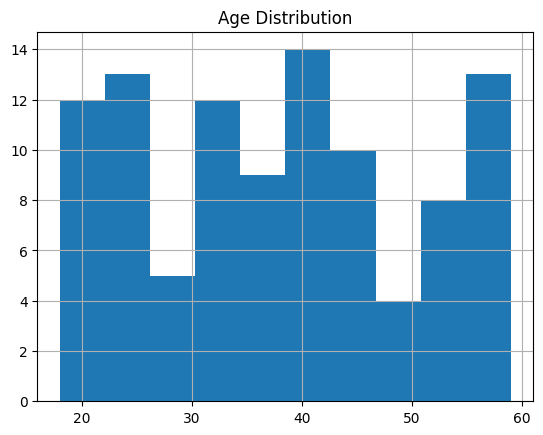

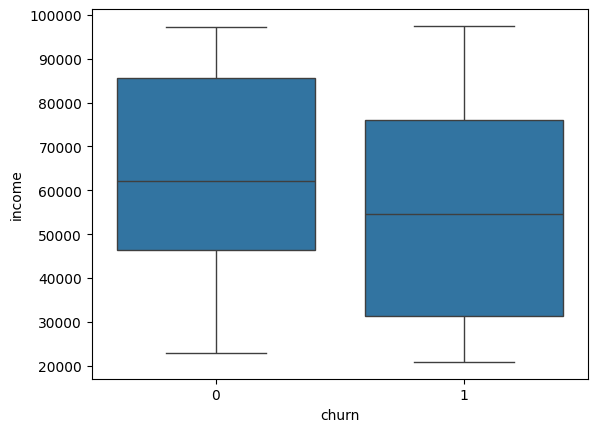

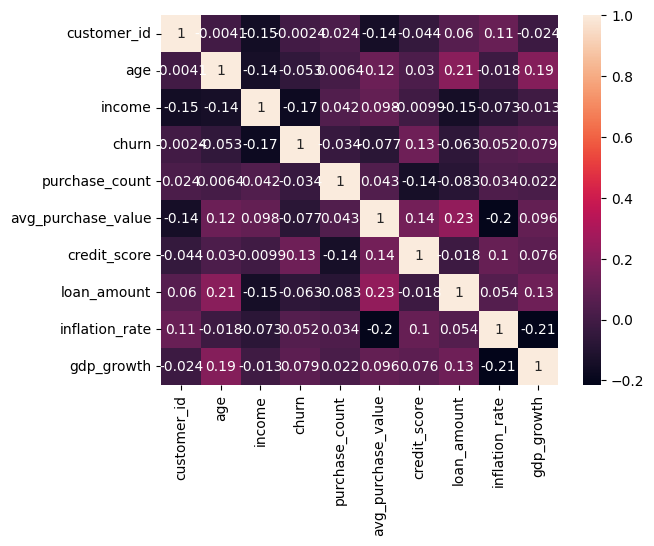

In [18]:
# Age Distribution

import seaborn as sns
import matplotlib.pyplot as plt
df['age'].hist()
plt.title("Age Distribution")
plt.show()

# Income vs Churn
sns.boxplot(x='churn', y='income', data=df)
plt.show()

# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


## Feature Engineering

In [19]:
df['total_spent'] = df['purchase_count'] * df['avg_purchase_value']

## Save Final Dataset

In [20]:
df.to_csv(r"C:\Users\tanaa\Downloads\cleaned_data.csv", index=False)

print(" Final dataset saved successfully")

 Final dataset saved successfully


## Data Profiling Report

In [21]:
html_content = f"""
<h1>Data Profiling Report</h1>

<p>Shape: {df.shape}</p>

<h2>Missing Values</h2>
{df.isnull().sum().to_frame().to_html()}

<h2>Summary</h2>
{df.describe().to_html()}
"""

with open(r"C:\Users\tanaa\Downloads\data_profile_report.html", "w") as f:
    f.write(html_content)

print(" HTML Report Saved")

 HTML Report Saved
